Imports:

In [102]:
import requests
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as mt
import scipy
from scipy.stats import norm
from scipy.stats import ttest_1samp


Visual Crossing API and Dataframe Creation:

In [103]:
# Break down and build up string 
url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/Washington,DC/"
start_date = "-06-01"
separator = "/"
end_date = "-06-30" 
final_append = "?key="
visual_crossing_API_KEY = "GW4267MR27NGP7JH2XVMMMFGP"
include = "&include=days"
include_elements = "&elements=datetime,address,feelslike,humidity,tempmax,tempmin,temp,precip,windspeed,conditions"
month_list = [requests.get(url + str(x) + start_date + separator + str(x) + end_date + final_append + visual_crossing_API_KEY + include + include_elements) for x in range(2025, 2022, -1)]
data_list = [data.json() for data in month_list]

three_year_dfs = [pd.DataFrame(data['days']) for data in data_list]

# Capitalize Columns
for x in range(len(three_year_dfs)):
    three_year_dfs[x].columns = three_year_dfs[x].columns.str.title()

# Display Dataframes for all 3 years 
print("June 2025")
display(three_year_dfs[0])
print("June 2024")
display(three_year_dfs[1])
print("June 2023")
display(three_year_dfs[2])


# Now we have the mean and SD so we can calulate the Z-Score by loading in the past 7 days to see if they fit the mean
seven_day_forecast = requests.get(url + "2026-06-08" + separator + "2026-06-14" + final_append + visual_crossing_API_KEY + include + include_elements)
seven_day_forecast = seven_day_forecast.json()
seven_day_forecast =pd.DataFrame(seven_day_forecast['days'])

# Capitalize Columns
seven_day_forecast.columns = seven_day_forecast.columns.str.title()

# Display 7-Day Weather Data
print("7 Day Weather June 8th - June 14th")
display(seven_day_forecast)


June 2025


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
0,2025-06-01,69.2,48.8,60.5,60.3,52.7,0.000,16.9,Partially cloudy
1,2025-06-02,74.1,51.8,64.3,64.3,51.4,0.000,11.4,Partially cloudy
2,2025-06-03,80.0,55.9,67.9,67.9,59.6,0.000,9.1,Partially cloudy
3,2025-06-04,84.0,61.9,72.4,72.8,67.7,0.000,13.6,Partially cloudy
4,2025-06-05,83.0,66.8,74.4,75.1,73.3,0.000,12.6,Partially cloudy
5,2025-06-06,83.1,67.7,74.8,75.5,76.9,0.000,9.1,Partially cloudy
6,2025-06-07,85.9,70.0,76.5,77.0,73.4,0.160,12.3,"Rain, Partially cloudy"
7,2025-06-08,75.6,70.0,72.7,72.7,80.2,0.066,11.3,"Rain, Overcast"
8,2025-06-09,82.9,68.0,74.4,74.9,78.4,0.011,12.5,"Rain, Partially cloudy"
9,2025-06-10,84.8,71.9,77.1,77.0,68.4,0.000,14.7,Partially cloudy


June 2024


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
0,2024-06-01,80.9,58.7,70.5,70.4,49.1,0.000,14.0,Partially cloudy
1,2024-06-02,81.1,64.5,73.1,73.3,61.7,0.000,18.1,Partially cloudy
2,2024-06-03,84.6,70.0,77.5,78.0,64.0,0.011,9.0,"Rain, Partially cloudy"
3,2024-06-04,88.0,69.6,78.9,79.7,67.5,0.000,19.2,Partially cloudy
4,2024-06-05,82.1,71.8,76.2,76.8,82.2,0.426,14.6,"Rain, Overcast"
5,2024-06-06,85.9,74.9,79.7,81.4,73.2,0.000,17.0,Partially cloudy
6,2024-06-07,86.9,72.7,79.3,78.6,45.1,0.000,22.4,Partially cloudy
7,2024-06-08,83.9,64.8,76.0,75.5,41.7,0.000,16.0,Partially cloudy
8,2024-06-09,83.0,70.7,76.7,76.7,45.5,0.000,20.8,Partially cloudy
9,2024-06-10,82.1,64.7,74.3,74.2,43.2,0.000,18.0,Partially cloudy


June 2023


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
0,2023-06-01,83.6,58.6,72.1,72.0,62.8,0.000,11.2,Partially cloudy
1,2023-06-02,92.6,63.5,77.6,77.4,58.4,0.000,9.8,Clear
2,2023-06-03,83.7,62.8,75.3,75.6,64.6,0.000,17.5,Partially cloudy
3,2023-06-04,75.6,60.8,66.7,66.7,62.5,0.000,13.3,Partially cloudy
4,2023-06-05,79.8,58.8,69.5,69.5,56.9,0.000,13.2,Partially cloudy
5,2023-06-06,82.8,60.5,72.6,72.3,41.5,0.000,16.1,Partially cloudy
6,2023-06-07,79.7,62.3,72.1,72.1,41.7,0.000,15.7,Partially cloudy
7,2023-06-08,77.7,60.5,68.7,68.7,48.3,0.000,13.7,Partially cloudy
8,2023-06-09,75.6,59.4,68.4,68.4,46.8,0.000,14.9,Partially cloudy
9,2023-06-10,86.9,58.6,73.2,72.5,46.4,0.000,14.4,Partially cloudy


7 Day Weather June 8th - June 14th


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
0,2026-06-08,79.7,68.9,73.9,73.9,58.8,0.000,12.2,Partially cloudy
1,2026-06-09,83.1,63.8,72.7,72.7,55.1,0.000,12.3,Partially cloudy
2,2026-06-10,89.1,71.1,77.6,79.2,76.0,0.097,13.5,"Rain, Overcast"
3,2026-06-11,96.9,73.1,83.9,87.5,69.2,0.003,13.1,Partially cloudy
4,2026-06-12,97.9,72.0,81.7,84.7,71.9,0.111,19.7,"Rain, Partially cloudy"
5,2026-06-13,89.9,71.9,81.3,80.9,55.6,0.000,13.4,Partially cloudy
6,2026-06-14,93.6,72.2,82.1,84.1,63.7,0.010,22.1,Partially cloudy


Functions:

In [104]:
def display_content(label: str, x_axis: str, points_color="orange") -> float: # Return float for mean used in Hypothesis Testing Function

    mean = 0
    standard_deviation = 0
    square = lambda x: x ** 2

    # Find the mean
    for x in range(len(three_year_dfs)):
        mean += three_year_dfs[x][label].mean()
        if x == len(three_year_dfs) - 1:
            mean = mean / len(three_year_dfs) 
    
    # Find the Standard Deviation 
    for index in range(len(three_year_dfs)):
        for item in three_year_dfs[index][label]:
            standard_deviation += square((item - mean))
    
    standard_deviation = math.sqrt(standard_deviation / (len(three_year_dfs[0]) + len(three_year_dfs[1]) + len(three_year_dfs[2]) - 1)) # n - 1: for sample standard deviation since we are using a sample of the total June months ever
    
    formatted_labels = {
        "Humidity":"Humidity",
        "Temp":"Temperature",
        "Tempmax":"Max Temperature",
        "Tempmin":"Min Temperature",
        "Feelslike":"Feels Like",
        "Precip":"Precipitation",
        "Windspeed":"Windspeed",
    }
    formatted_label = formatted_labels.get(label)
    z_scores = []

    for val in seven_day_forecast[label]:
        z_scores.append((val - mean) / standard_deviation)
    
    seven_day_forecast[f'{label} Z-Score'] = z_scores
    
    # Spaceing Lines
    x = np.linspace(mean - (4 * standard_deviation), mean + (4 * standard_deviation), 1000)
    
    y = norm.pdf(x, mean, standard_deviation)
    
    # Start of plot 
    mt.figure(figsize=(12, 8))
    mt.plot(x,y, label="Histroical June Distribution")
    
    # Mean Line
    mt.axvline(mean,color="orange", linestyle="-", linewidth=2, label="Mean")
    
    # Mean Temperature Line
    mt.text(mean, min(y) * .9, f"{round(mean,1)}\n Mean {formatted_label}", rotation = 0, ha = 'center')
    
    for z in [-3, -2, -1, 1, 2, 3]:
        pcnt = ""
        if z % 3 == 0:
            pcnt = "99.7%"
        elif z % 2 == 0:
            pcnt = "95%"
        else:
            pcnt = "68%"
        mt.axvline(mean + z * standard_deviation, color='blue', linestyle="--", alpha = .5)
        mt.text(mean + z * standard_deviation, max(y) * .8, f"{z}σ = ({pcnt})", rotation = 90, ha = 'center')
    
    # label_list
    label_list = seven_day_forecast[label]
    
    points = norm.pdf(label_list, mean, standard_deviation)
    
    mt.plot(label_list, points, '-o', color=points_color, label=f'June 8-14 {formatted_label}')
    
    mt.xlabel(x_axis)
    mt.ylabel("Probability Density")
    mt.title(f"Week of June 8th - June 14th {formatted_label} vs Historical Samples")
    mt.legend()
    mt.show()
    print(f"{formatted_labels.get(label)} Table for the Week June 8th - 14th")
    display(seven_day_forecast[['Datetime',label,f'{label} Z-Score']])
    return float(mean)


# Function for hypothesis testing
def hypothesis_test(label:str, mean:float, alpha:float):

    print(f"""Hypothesis Testing for {label} with Alpha = .05:\n 
    - Null Hypothesis H₀:  M₀ = Avg = The average {label} during the week June 8th - 14th, 2026 is equal to the historical June average.\n
    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average {label} during the week June 8th - 14th, 2026 is different from the historical June average.\n""")
    
    week_data = seven_day_forecast[label]
    stat, p_value = ttest_1samp(week_data, popmean=mean)
    print(f"Week Mean: {round(week_data.mean(),2)}")
    print(f"Historical Mean: {round(mean,2)}")
    print(f"T Statistic: {round(stat,4)}")
    print(f"P-Value: {round(p_value,4)}\n")

    if p_value > alpha:
        print("Based off the T-test, there is no significant difference between the historical June data and our week sample.")
        print("Fail to reject M₀\n")

    else:
        print("Based off the T-test, there is significant differences between the historical June data and our week sample.")
        print("Reject M₀\n")

    


Normal Distribution, Data Output, and Hypothesis Testing (t-test):
   - Z-Score indicates how many standard deviations the daily temperature is away from the 3 year historical mean.

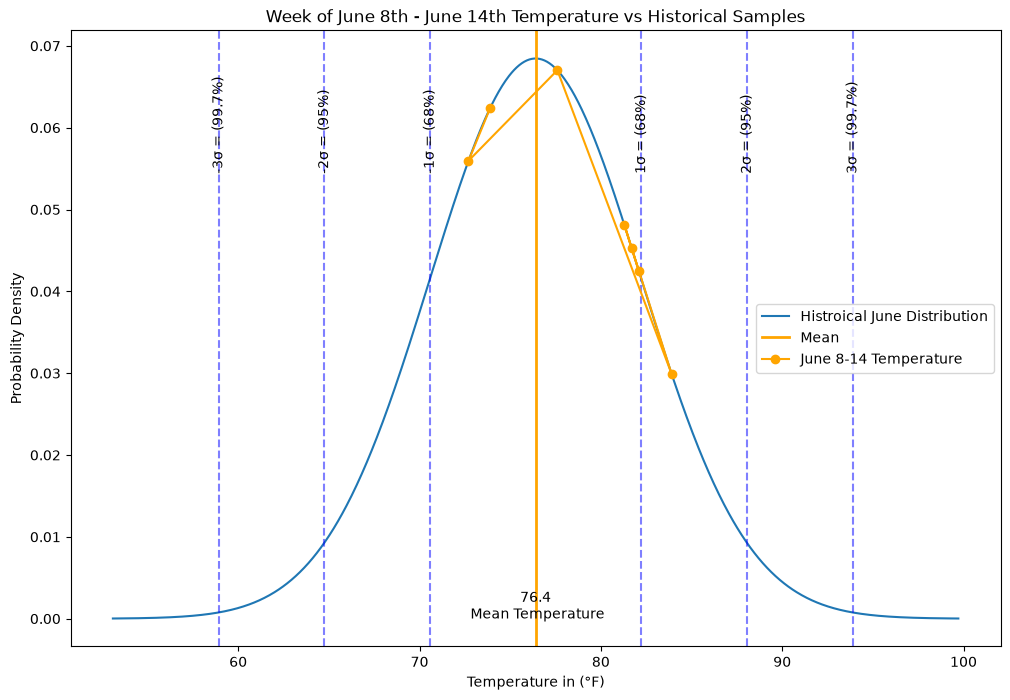

Temperature Table for the Week June 8th - 14th


,Datetime,Temp,Temp Z-Score
0,2026-06-08,73.9,-0.429158
1,2026-06-09,72.7,-0.635062
2,2026-06-10,77.6,0.205713
3,2026-06-11,83.9,1.286710
4,2026-06-12,81.7,0.909219
5,2026-06-13,81.3,0.840585
6,2026-06-14,82.1,0.977854


Hypothesis Testing for Temp with Alpha = .05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Temp during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Temp during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 79.03
Historical Mean: 76.4
T Statistic: 1.5958
P-Value: 0.1616

Based off the T-test, there is no significant difference between the historical June data and our week sample.
Fail to reject M₀



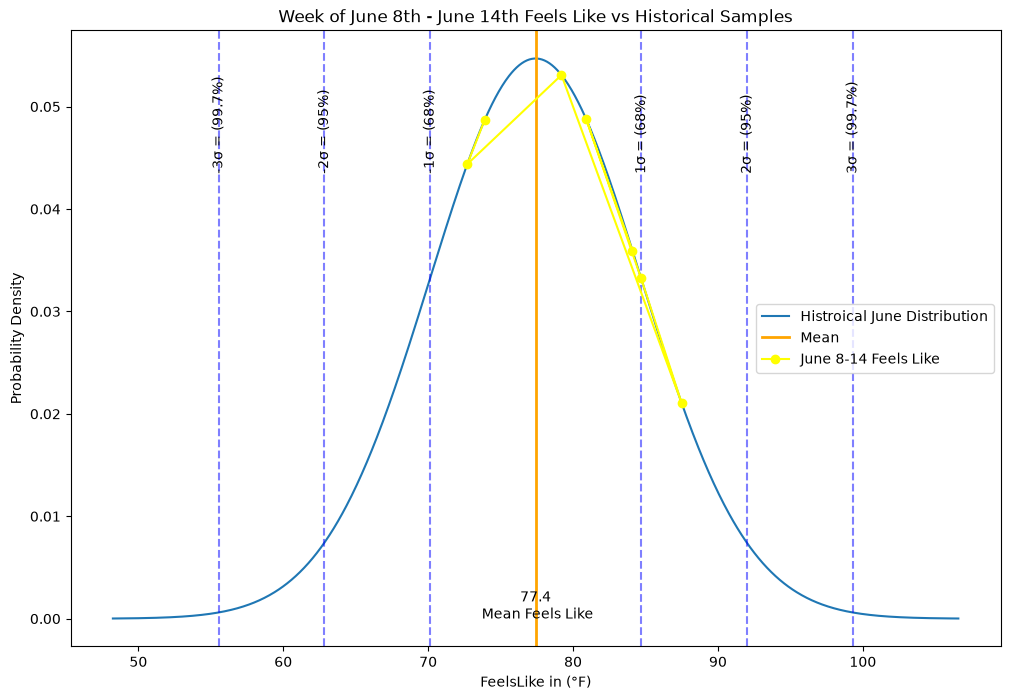

Feels Like Table for the Week June 8th - 14th


,Datetime,Feelslike,Feelslike Z-Score
0,2026-06-08,73.9,-0.482004
1,2026-06-09,72.7,-0.646532
2,2026-06-10,79.2,0.244658
3,2026-06-11,87.5,1.382640
4,2026-06-12,84.7,0.998743
5,2026-06-13,80.9,0.477739
6,2026-06-14,84.1,0.916479


Hypothesis Testing for Feelslike with Alpha = .05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Feelslike during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Feelslike during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 80.43
Historical Mean: 77.42
T Statistic: 1.4325
P-Value: 0.202

Based off the T-test, there is no significant difference between the historical June data and our week sample.
Fail to reject M₀



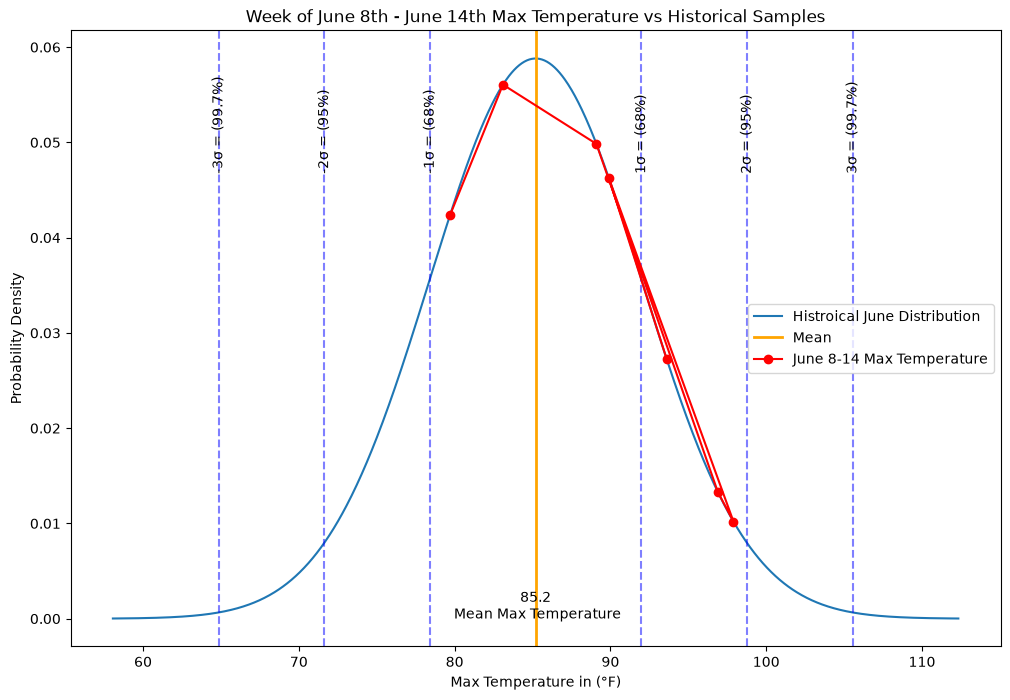

Max Temperature Table for the Week June 8th - 14th


,Datetime,Tempmax,Tempmax Z-Score
0,2026-06-08,79.7,-0.810429
1,2026-06-09,83.1,-0.309234
2,2026-06-10,89.1,0.575228
3,2026-06-11,96.9,1.725028
4,2026-06-12,97.9,1.872438
5,2026-06-13,89.9,0.693156
6,2026-06-14,93.6,1.238574


Hypothesis Testing for Tempmax with Alpha = .05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Tempmax during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Tempmax during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 90.03
Historical Mean: 85.2
T Statistic: 1.8794
P-Value: 0.1092

Based off the T-test, there is no significant difference between the historical June data and our week sample.
Fail to reject M₀



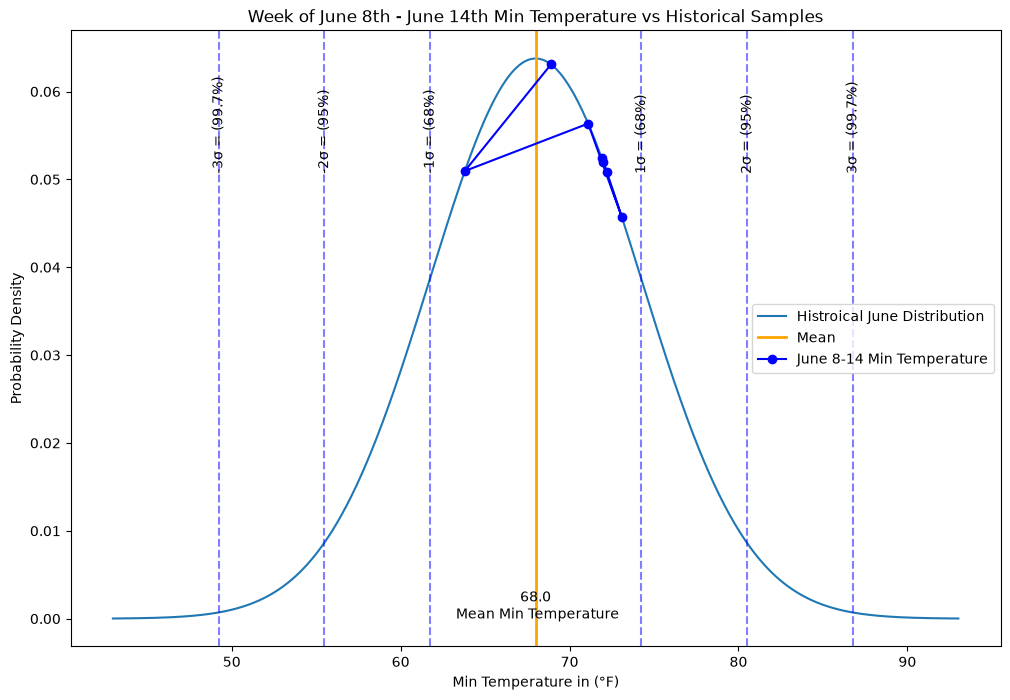

Min Temperature Table for the Week June 8th - 14th


,Datetime,Tempmin,Tempmin Z-Score
0,2026-06-08,68.9,0.145432
1,2026-06-09,63.8,-0.669628
2,2026-06-10,71.1,0.497027
3,2026-06-11,73.1,0.816659
4,2026-06-12,72.0,0.640861
5,2026-06-13,71.9,0.624880
6,2026-06-14,72.2,0.672825


Hypothesis Testing for Tempmin with Alpha = .05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Tempmin during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Tempmin during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 70.43
Historical Mean: 67.99
T Statistic: 2.013
P-Value: 0.0908

Based off the T-test, there is no significant difference between the historical June data and our week sample.
Fail to reject M₀



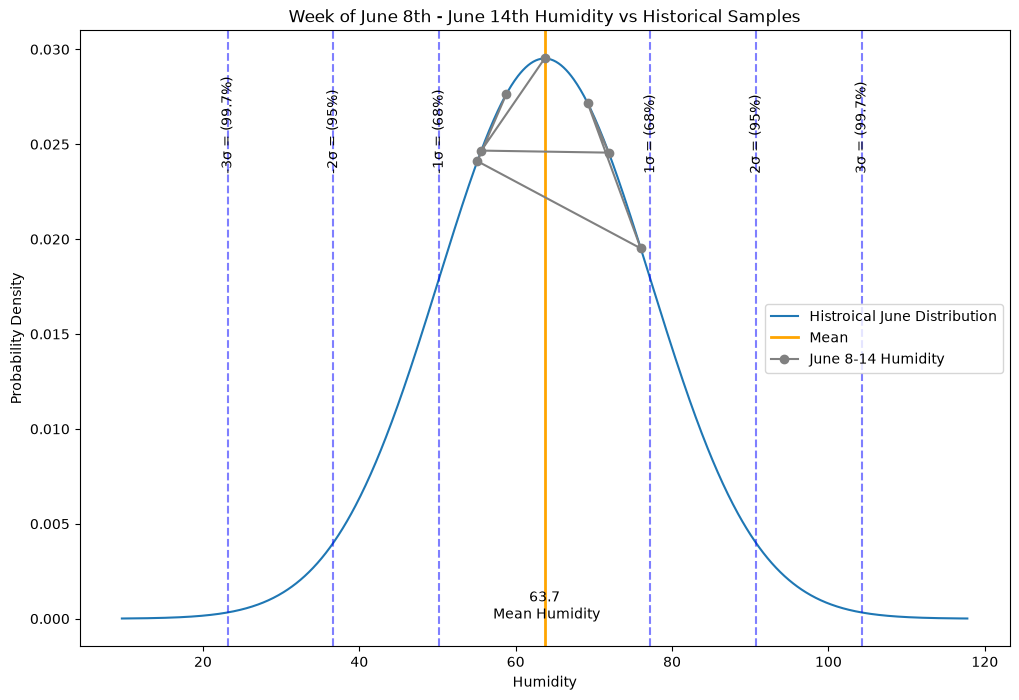

Humidity Table for the Week June 8th - 14th


,Datetime,Humidity,Humidity Z-Score
0,2026-06-08,58.8,-0.362610
1,2026-06-09,55.1,-0.636355
2,2026-06-10,76.0,0.909936
3,2026-06-11,69.2,0.406837
4,2026-06-12,71.9,0.606597
5,2026-06-13,55.6,-0.599363
6,2026-06-14,63.7,-0.000082


Hypothesis Testing for Humidity with Alpha = .05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Humidity during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Humidity during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 64.33
Historical Mean: 63.7
T Statistic: 0.2009
P-Value: 0.8474

Based off the T-test, there is no significant difference between the historical June data and our week sample.
Fail to reject M₀



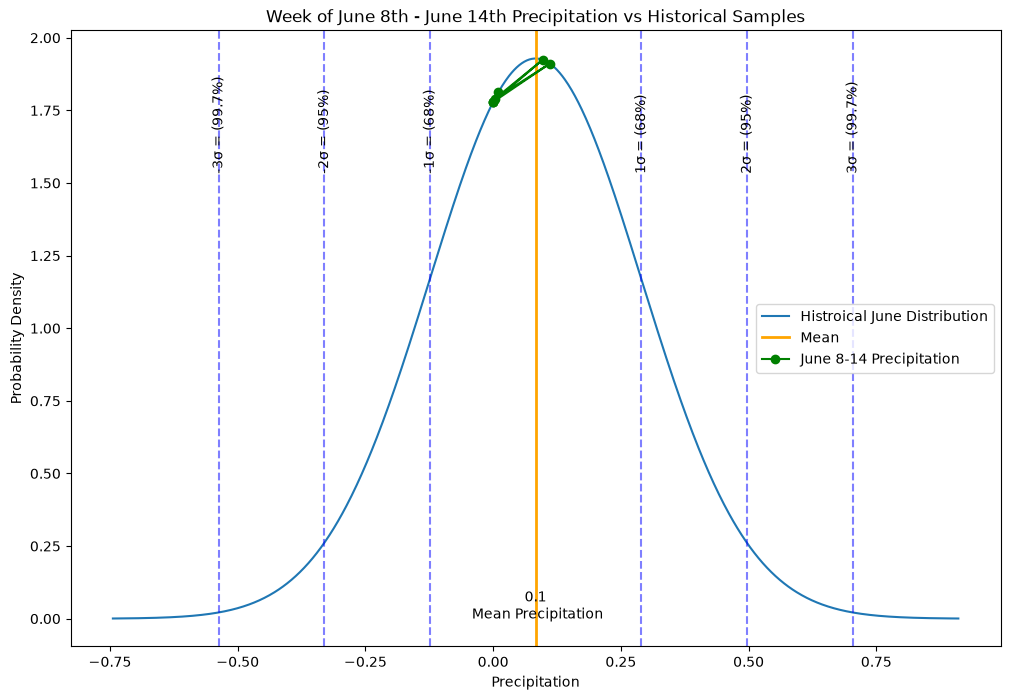

Precipitation Table for the Week June 8th - 14th


,Datetime,Precip,Precip Z-Score
0,2026-06-08,0.000,-0.401805
1,2026-06-09,0.000,-0.401805
2,2026-06-10,0.097,0.067147
3,2026-06-11,0.003,-0.387301
4,2026-06-12,0.111,0.134830
5,2026-06-13,0.000,-0.401805
6,2026-06-14,0.010,-0.353459


Hypothesis Testing for Precip with Alpha = .05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Precip during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Precip during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 0.03
Historical Mean: 0.08
T Statistic: -2.7399
P-Value: 0.0337

Based off the T-test, there is significant differences between the historical June data and our week sample.
Reject M₀



In [105]:
hypothesis_test("Temp", display_content("Temp", "Temperature in (°F)", "orange"), .05)
hypothesis_test("Feelslike",display_content("Feelslike", "FeelsLike in (°F)", "yellow"), .05)
hypothesis_test("Tempmax",display_content("Tempmax", "Max Temperature in (°F)", "red"), .05)
hypothesis_test("Tempmin",display_content("Tempmin", "Min Temperature in (°F)", "blue"), .05)
hypothesis_test("Humidity",display_content("Humidity", "Humidity", "gray"), .05)
hypothesis_test("Precip",display_content("Precip", "Precipitation", "green"), .05)

Hypothesis Testing for All Weather Attributes: 
    - Null Hypothesis H₀:  M₀ = Avg = The average (Temperature, Feels Like Temperature, Max Temperature, Min Temperature, Humidity, Precipitation) during the week June 8th - 14th, 2026 is equal to the historical June average.
    - Alternative Hypothesis 𝐻a:  H₀ ≠ Avg =  The average (Temperature, Feels Like Temperature, Max Temperature, Min Temperature, Humidity, Precipitation) during the week June 8th - 14th, 2026 is different from the historical June average.